# Statistical Analysis for S-Mapper Paper

This notebook provides:
- **(A) Wilcoxon Signed-Rank Test** — S-Mapper vs. Mapper across all 9 benchmark datasets
- **(B) Sensitivity Analysis** — TSC vs. number of iterations and population size (Trefoil dataset)

Run from the `examples/` directory.

In [11]:
import sys, os
_base = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(_base, 'kepler-mapper'))
sys.path.insert(0, os.path.join(_base, 'mealpy'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import kmapper as km
import kmapper.evaluate as evaluate

SEED = 42
np.random.seed(SEED)

## (A) Wilcoxon Signed-Rank Test

Compare S-Mapper (PSO & GWO) against Mapper and D-Mapper baselines across 9 benchmark datasets using the paired Wilcoxon signed-rank test (two-sided, α = 0.05).

In [12]:
datasets = [
    "Disjoint circles", "Intersecting circles", "Trefoil",
    "Cat", "Lion", "Horse", "Human", "Diabetes", "COVID-19"
]

# TSC values from experimental results (result.md)
mapper_tsc   = np.array([0.825,  0.725,  0.503,  0.750,  0.507,  0.545,  0.809,  0.340,  0.3978])
dmapper_tsc  = np.array([0.818,  0.820,  0.390,  0.756,  0.597,  0.634,  0.4944, 0.299,  0.2852])
smapper_pso  = np.array([0.8346, 0.8050, 0.5359, 0.7952, 0.7815, 0.8303, 0.821,  0.3886, 0.5402])
smapper_gwo  = np.array([0.8346, 0.8050, 0.5359, 0.7952, 0.7815, 0.8303, 0.821,  0.3886, 0.5402])

comparisons = [
    ("S-Mapper (PSO)", "Mapper",   smapper_pso, mapper_tsc),
    ("S-Mapper (GWO)", "Mapper",   smapper_gwo, mapper_tsc),
    ("S-Mapper (PSO)", "D-Mapper", smapper_pso, dmapper_tsc),
    ("S-Mapper (GWO)", "D-Mapper", smapper_gwo, dmapper_tsc),
]

print(f"{'Comparison':<35} {'Statistic':>10} {'p-value':>10} {'Significant (α=0.05)':>22}")
print("-" * 80)
for (a_name, b_name, a_vals, b_vals) in comparisons:
    stat, p = wilcoxon(a_vals, b_vals, alternative='greater')
    sig = "Yes ✓" if p < 0.05 else "No"
    print(f"{a_name} vs {b_name:<15} {stat:>10.2f} {p:>10.4f} {sig:>22}")



Comparison                           Statistic    p-value   Significant (α=0.05)
--------------------------------------------------------------------------------
S-Mapper (PSO) vs Mapper               45.00     0.0020                  Yes ✓
S-Mapper (GWO) vs Mapper               45.00     0.0020                  Yes ✓
S-Mapper (PSO) vs D-Mapper             44.00     0.0039                  Yes ✓
S-Mapper (GWO) vs D-Mapper             44.00     0.0039                  Yes ✓


## (B) Sensitivity Analysis

TSC as a function of **(a) number of iterations** and **(b) population size** — evaluated on the Trefoil dataset using PSO.

In [13]:
from dyneusr.datasets import make_trefoil
from mealpy.swarm_based.PSO import OriginalPSO
from mealpy import FloatVar

np.random.seed(SEED)
_td_sens  = make_trefoil(size=100)
data_sens = _td_sens.data
mapper_s  = km.KeplerMapper(verbose=0)
proj_sens = mapper_s.fit_transform(data_sens, projection=[0])

SMAPPER_TSC = {'trefoil': 0.5359}

def obj_sens(X):
    n = int(round(float(X[0])))
    a = float(X[1])
    try:
        cover = km.Cover(n_cubes=n, perc_overlap=a)
        graph = mapper_s.map(proj_sens, data_sens, cover=cover)
        tsc = evaluate.compute_SC_adj(
            data_sens, proj_sens, graph, cover, type='k', N=50
        )
        return -tsc
    except Exception:
        return 3.0

problem_sens = {
    'obj_func': obj_sens,
    'bounds': [
        FloatVar(lb=5, ub=25, name='n'),
        FloatVar(lb=0.1, ub=0.7, name='a'),
    ],
    'minmax': 'min',
}


In [14]:
EPOCHS = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]
conv_tsc = []

for ep in EPOCHS:
    print(f'  epoch={ep} ...', end=' ', flush=True)
    m = OriginalPSO(epoch=ep, pop_size=20)
    g_best = m.solve(problem_sens, seed=SEED)
    best_tsc = -g_best.target.fitness
    conv_tsc.append(best_tsc)
    print(f'TSC = {best_tsc:.4f}')


  epoch=1 ... 

100%|██████████| 50/50 [00:00<00:00, 138.55it/s]
INFO:mealpy.swarm_based.PSO.OriginalPSO:Solving single objective optimization problem.


SC:-0.2379384264058599
SC_norm:0.38103078679707003
TSR:0.03125
SC_adj:0.20614039339853502


100%|██████████| 50/50 [00:00<00:00, 205.95it/s]


SC:0.03079740735574355
SC_norm:0.5153987036778718
TSR:0.08333333333333333
SC_adj:0.29936601850560257


...

SC:-0.0004918888393610604
SC_norm:0.4997540555803195
TSR:0.2857142857142857
SC_adj:0.3927341706473026


100%|██████████| 50/50 [00:00<00:00, 101.67it/s]


SC:0.17542368352102206
SC_norm:0.5877118417605111
TSR:0.1
SC_adj:0.3438559208802555


100%|██████████| 50/50 [00:00<00:00, 70.71it/s]
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 50, Current best: -0.61472075, Global best: -0.61472075, Runtime: 12.31713 seconds


SC:0.08181439205964457
SC_norm:0.5409071960298223
TSR:0.125
SC_adj:0.33295359801491115
TSC = 0.6147


In [15]:
POP_SIZES    = [5, 10, 15, 20, 30, 50]
pop_tsc_list = []

for ps in POP_SIZES:
    print(f'  pop_size={ps} ...', end=' ', flush=True)
    m        = OriginalPSO(epoch=15, pop_size=ps)
    g_best   = m.solve(problem_sens, seed=SEED)
    best_tsc = -g_best.target.fitness
    pop_tsc_list.append(best_tsc)
    print(f'TSC = {best_tsc:.4f}')



  pop_size=5 ... 

100%|██████████| 50/50 [00:01<00:00, 38.09it/s]
INFO:mealpy.swarm_based.PSO.OriginalPSO:Solving single objective optimization problem.


SC:-0.2379384264058599
SC_norm:0.38103078679707003
TSR:0.03125
SC_adj:0.20614039339853502


100%|██████████| 50/50 [00:00<00:00, 52.87it/s]


SC:0.03079740735574355
SC_norm:0.5153987036778718
TSR:0.08333333333333333
SC_adj:0.29936601850560257


...

SC:0.1529853244151884
SC_norm:0.5764926622075942
TSR:0.2
SC_adj:0.38824633110379714


100%|██████████| 50/50 [00:00<00:00, 226.92it/s]


SC:0.1529853244151884
SC_norm:0.5764926622075942
TSR:0.2
SC_adj:0.38824633110379714


100%|██████████| 50/50 [00:00<00:00, 221.72it/s]
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 15, Current best: -0.5359465421546223, Global best: -0.5359465421546223, Runtime: 13.26830 seconds


SC:0.1437861686184895
SC_norm:0.5718930843092448
TSR:0.5
SC_adj:0.5359465421546223
TSC = 0.5359


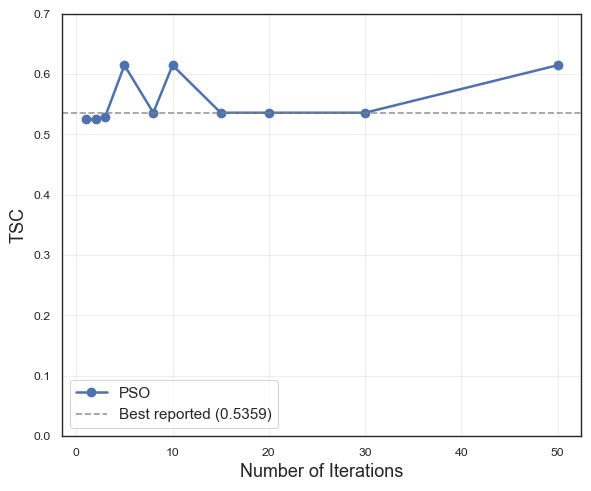

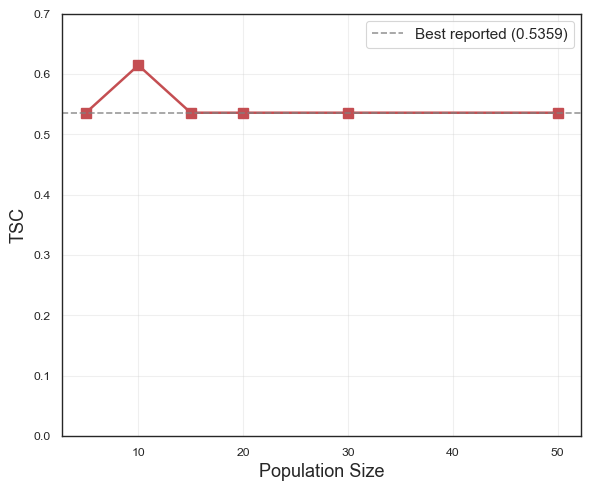

In [18]:
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.plot(EPOCHS, conv_tsc, 'b-o', markersize=6, linewidth=1.8, label='PSO')
ax1.axhline(y=SMAPPER_TSC['trefoil'], color='gray', linestyle='--',
            alpha=0.8, label=f'Best reported ({SMAPPER_TSC["trefoil"]})')
ax1.set_xlabel('Number of Iterations', fontsize=13)
ax1.set_ylabel('TSC', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.0, 0.70])
plt.tight_layout()
plt.savefig('sensitivity_iterations.pdf', bbox_inches='tight', dpi=300)
plt.savefig('sensitivity_iterations.eps', bbox_inches='tight', dpi=300)
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.plot(POP_SIZES, pop_tsc_list, 'r-s', markersize=7, linewidth=1.8)
ax2.axhline(y=SMAPPER_TSC['trefoil'], color='gray', linestyle='--',
            alpha=0.8, label=f'Best reported ({SMAPPER_TSC["trefoil"]})')
ax2.set_xlabel('Population Size', fontsize=13)
ax2.set_ylabel('TSC', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.0, 0.70])
plt.tight_layout()
plt.savefig('sensitivity_population.pdf', bbox_inches='tight', dpi=300)
plt.savefig('sensitivity_population.eps', bbox_inches='tight', dpi=300)
plt.show()